In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


## **Dataset loaded**

In [2]:
df = pd.read_csv("/content/drive/MyDrive/dataset_12000_records.csv")

In [3]:
df.shape

(12000, 36)

In [4]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'BMI', 'Smoking_Status',
       'Alcohol_Consumption', 'Exercise_Frequency', 'Hypertension', 'Diabetes',
       'Chronic_Kidney_Disease', 'Coronary_Artery_Disease', 'Previous_Stroke',
       'Atrial_Fibrillation', 'Previous_HF_Admissions',
       'Previous_Hospital_Admissions', 'Heart_Failure_Type', 'NYHA_Class',
       'Ejection_Fraction', 'Systolic_BP', 'Diastolic_BP', 'Heart_Rate',
       'Oxygen_Saturation', 'Creatinine', 'Sodium', 'Potassium', 'Hemoglobin',
       'Blood_Glucose', 'BNP', 'Length_of_Stay', 'ICU_Admission',
       'Emergency_Admission', 'Beta_Blocker', 'ACE_ARB', 'Diuretic',
       'SGLT2_Inhibitor', 'Readmitted_30_Days'],
      dtype='object')

In [5]:
df.dtypes

,0
Patient_ID,object
Age,int64
Gender,object
BMI,float64
Smoking_Status,object
Alcohol_Consumption,object
Exercise_Frequency,int64
Hypertension,int64
Diabetes,int64
Chronic_Kidney_Disease,int64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Patient_ID                    12000 non-null  object 
 1   Age                           12000 non-null  int64  
 2   Gender                        12000 non-null  object 
 3   BMI                           12000 non-null  float64
 4   Smoking_Status                12000 non-null  object 
 5   Alcohol_Consumption           12000 non-null  object 
 6   Exercise_Frequency            12000 non-null  int64  
 7   Hypertension                  12000 non-null  int64  
 8   Diabetes                      12000 non-null  int64  
 9   Chronic_Kidney_Disease        12000 non-null  int64  
 10  Coronary_Artery_Disease       12000 non-null  int64  
 11  Previous_Stroke               12000 non-null  int64  
 12  Atrial_Fibrillation           12000 non-null  int64  
 13  P

In [7]:
df.describe()

,Age,BMI,Exercise_Frequency,Hypertension,Diabetes,Chronic_Kidney_Disease,Coronary_Artery_Disease,Previous_Stroke,Atrial_Fibrillation,Previous_HF_Admissions,...,Blood_Glucose,BNP,Length_of_Stay,ICU_Admission,Emergency_Admission,Beta_Blocker,ACE_ARB,Diuretic,SGLT2_Inhibitor,Readmitted_30_Days
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,67.396417,27.790903,1.018583,0.412417,0.296667,0.268000,0.401500,0.183083,0.277333,0.631083,...,118.077890,204.936134,8.146667,0.339917,0.511667,0.804167,0.762000,0.576667,0.395000,0.300000
std,13.079380,5.035375,1.036819,0.492290,0.456807,0.442936,0.490222,0.386751,0.447701,0.874765,...,32.696853,203.739039,6.472865,0.473700,0.499885,0.396857,0.425877,0.494108,0.488871,0.458277
min,30.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,70.000000,50.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,60.000000,24.299963,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,92.609403,84.818008,3.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
50%,68.000000,27.780840,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,115.999968,142.847005,6.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
75%,77.000000,31.246772,2.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,...,139.825765,248.264021,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,95.000000,45.975566,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000,...,258.524090,4097.436155,30.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
df['Exercise_Frequency'].value_counts()

,count
Exercise_Frequency,
0,4757
1,3627
2,2471
3,926
4,219


In [9]:
df.isna().sum()

,0
Patient_ID,0
Age,0
Gender,0
BMI,0
Smoking_Status,0
Alcohol_Consumption,0
Exercise_Frequency,0
Hypertension,0
Diabetes,0
Chronic_Kidney_Disease,0


In [10]:
df.head()

,Patient_ID,Age,Gender,BMI,Smoking_Status,Alcohol_Consumption,Exercise_Frequency,Hypertension,Diabetes,Chronic_Kidney_Disease,...,Blood_Glucose,BNP,Length_of_Stay,ICU_Admission,Emergency_Admission,Beta_Blocker,ACE_ARB,Diuretic,SGLT2_Inhibitor,Readmitted_30_Days
0,PT_00001,65,Female,25.564766,No,No,0,1,0,0,...,95.586026,118.407920,13,0,1,1,1,0,0,0
1,PT_00002,83,Male,30.503110,Yes,Yes,1,1,1,1,...,142.445450,421.440746,4,1,1,1,1,1,1,1
2,PT_00003,76,Male,21.934792,No,No,0,1,1,1,...,158.669171,240.351673,5,0,0,1,1,0,1,0
3,PT_00004,72,Female,22.048039,No,Yes,0,0,1,0,...,145.531173,334.414121,13,0,1,1,1,1,0,1
4,PT_00005,54,Male,27.102739,No,No,3,0,0,0,...,94.644198,71.006274,5,1,1,0,1,0,0,0


In [11]:
df.select_dtypes(include=['object','category']).columns

Index(['Patient_ID', 'Gender', 'Smoking_Status', 'Alcohol_Consumption',
       'Heart_Failure_Type'],
      dtype='object')

### **Label Encoding**

In [12]:
le = LabelEncoder()

In [13]:
df['Gender'] = le.fit_transform(df['Gender'])
df['Smoking_Status'] = le.fit_transform(df['Smoking_Status'])
df['Alcohol_Consumption'] = le.fit_transform(df['Alcohol_Consumption'])

In [14]:
print(df)

      Patient_ID  Age  Gender        BMI  Smoking_Status  Alcohol_Consumption  \
0       PT_00001   65       0  25.564766               0                    0   
1       PT_00002   83       1  30.503110               1                    1   
2       PT_00003   76       1  21.934792               0                    0   
3       PT_00004   72       0  22.048039               0                    1   
4       PT_00005   54       1  27.102739               0                    0   
...          ...  ...     ...        ...             ...                  ...   
11995   PT_11996   38       0  26.447694               0                    0   
11996   PT_11997   87       0  31.303370               0                    1   
11997   PT_11998   62       1  35.160424               1                    0   
11998   PT_11999   85       1  28.831126               0                    0   
11999   PT_12000   68       1  30.701425               1                    0   

       Exercise_Frequency  

### **One-Hot Encoding**

In [15]:
df = pd.get_dummies(df, columns=['Heart_Failure_Type'], dtype=int)

In [16]:
print(df)

      Patient_ID  Age  Gender        BMI  Smoking_Status  Alcohol_Consumption  \
0       PT_00001   65       0  25.564766               0                    0   
1       PT_00002   83       1  30.503110               1                    1   
2       PT_00003   76       1  21.934792               0                    0   
3       PT_00004   72       0  22.048039               0                    1   
4       PT_00005   54       1  27.102739               0                    0   
...          ...  ...     ...        ...             ...                  ...   
11995   PT_11996   38       0  26.447694               0                    0   
11996   PT_11997   87       0  31.303370               0                    1   
11997   PT_11998   62       1  35.160424               1                    0   
11998   PT_11999   85       1  28.831126               0                    0   
11999   PT_12000   68       1  30.701425               1                    0   

       Exercise_Frequency  

### **Target identified and encoded correctly**

In [17]:
X = df.drop(['Patient_ID','Readmitted_30_Days'], axis=1)
y = df['Readmitted_30_Days']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [19]:
scalar = StandardScaler()

In [20]:
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

# **LogisticRegression**

In [21]:
lr = LogisticRegression()

In [22]:
lr.fit(X_train_scaled, y_train)

LogisticRegression()

In [23]:
y_pred = lr.predict(X_test_scaled)

In [24]:
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

In [25]:
print("Accuracy", accuracy_score(y_test, y_pred))
print("Precision", precision_score(y_test, y_pred))
print("Recall", recall_score(y_test, y_pred))
print("F1 Score", f1_score(y_test, y_pred))
print("ROC AUC", roc_auc_score(y_test, y_prob_lr))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy 0.895
Precision 0.8524096385542169
Recall 0.7861111111111111
F1 Score 0.8179190751445087
ROC AUC 0.956182208994709
Confusion Matrix
[[1582   98]
 [ 154  566]]


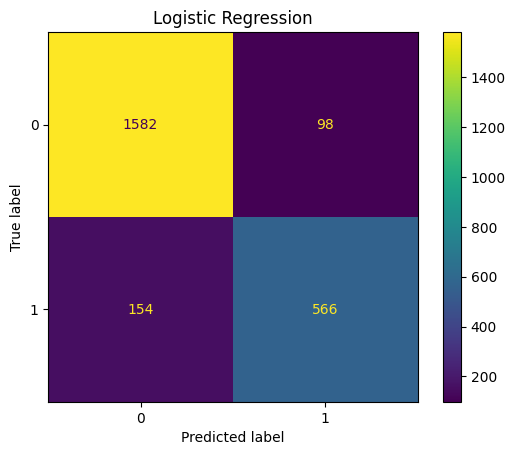

In [26]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()
plt.title("Logistic Regression")
plt.show()

# **KNN**

In [27]:
knn = KNeighborsClassifier(n_neighbors = 5)

In [28]:
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [29]:
y_pred_knn = knn.predict(X_test_scaled)

In [30]:
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

In [31]:
print("Accuracy", accuracy_score(y_test, y_pred_knn))
print("Precision", precision_score(y_test, y_pred_knn))
print("Recall", recall_score(y_test, y_pred_knn))
print("F1 Score", f1_score(y_test, y_pred_knn))
print("ROC AUC", roc_auc_score(y_test, y_prob_knn))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_knn))

Accuracy 0.8395833333333333
Precision 0.8290766208251473
Recall 0.5861111111111111
F1 Score 0.6867371847030106
ROC AUC 0.8784726355820106
Confusion Matrix
[[1593   87]
 [ 298  422]]


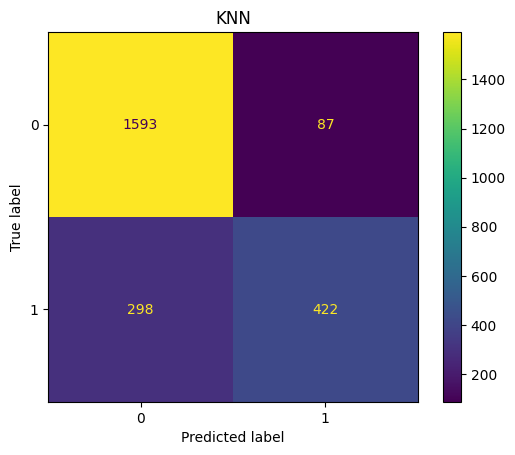

In [32]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_knn)).plot()
plt.title("KNN")
plt.show()

# **Dicision tree**

In [50]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)

In [51]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [52]:
y_pred_dt = dt.predict(X_test)

In [53]:
y_prob_dt = dt.predict_proba(X_test)[:, 1]

In [54]:
print("Accuracy", accuracy_score(y_test, y_pred_dt))
print("Precision", precision_score(y_test, y_pred_dt))
print("Recall", recall_score(y_test, y_pred_dt))
print("F1 Score", f1_score(y_test, y_pred_dt))
print("ROC AUC", roc_auc_score(y_test, y_prob_dt))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy 0.8383333333333334
Precision 0.7577639751552795
Recall 0.6777777777777778
F1 Score 0.7155425219941349
ROC AUC 0.8907415674603175
Confusion Matrix
[[1524  156]
 [ 232  488]]


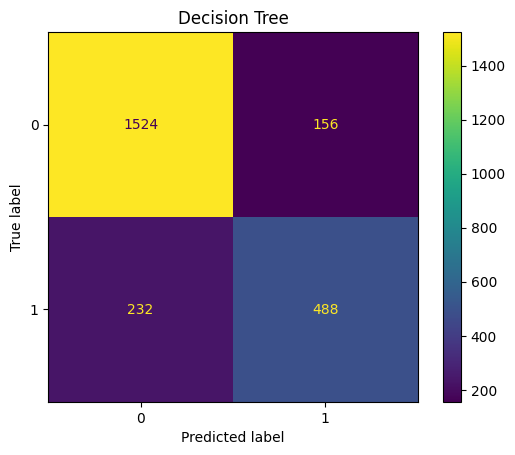

In [55]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_dt)).plot()
plt.title("Decision Tree")
plt.show()

# **Calculate ROC Curve**

In [56]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

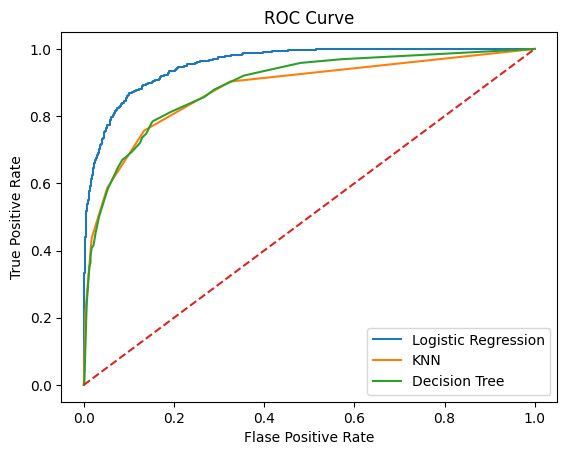

In [57]:
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
plt.plot(fpr_knn, tpr_knn, label='KNN')
plt.plot(fpr_dt, tpr_dt, label='Decision Tree')
plt.plot([0,1],[0,1], '--')
plt.xlabel("Flase Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# **Train vs test performance compared**

In [58]:
y_train_lr = lr.predict(X_train_scaled)
y_train_knn = knn.predict(X_train_scaled)
y_train_dt = dt.predict(X_train)


In [59]:
train_lr = accuracy_score(y_train, y_train_lr)
train_knn = accuracy_score(y_train, y_train_knn)
train_dt = accuracy_score(y_train, y_train_dt)

In [60]:
test_lr = accuracy_score(y_test, y_pred)
test_knn = accuracy_score(y_test, y_pred_knn)
test_dt = accuracy_score(y_test, y_pred_dt)

In [61]:
print("Logistic Regression", train_lr, test_lr)
print("KNN", train_knn, test_knn)
print("Decision Tree", train_dt, test_dt)

Logistic Regression 0.894375 0.895
KNN 0.8857291666666667 0.8395833333333333
Decision Tree 0.8513541666666666 0.8383333333333334


## **Calculate Gap**

In [62]:
print("LR gap:", train_lr - test_lr)
print("KNN gap:", train_knn - test_knn)
print("DT gap:", train_dt - test_dt)

LR gap: -0.0006249999999999867
KNN gap: 0.04614583333333333
DT gap: 0.01302083333333326


## **Final Comparison Table**

In [65]:
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_knn = roc_auc_score(y_test, y_prob_knn)
auc_dt = roc_auc_score(y_test, y_prob_dt)

final_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt)
    ],
    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_dt)
    ],
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_dt)
    ],
    'F1': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_dt)
    ],
    'ROC-AUC': [
        auc_lr,
        auc_knn,
        auc_dt
    ]
})

print(final_results.round(3))

                 Model  Accuracy  Precision  Recall     F1  ROC-AUC
0  Logistic Regression     0.895      0.852   0.786  0.818    0.956
1                  KNN     0.840      0.829   0.586  0.687    0.878
2        Decision Tree     0.838      0.758   0.678  0.716    0.891


In [66]:
final_results['Train Accuracy'] = [
    train_lr,
    train_knn,
    train_dt
]

final_results['Test Accuracy'] = [
    test_lr,
    test_knn,
    test_dt
]

final_results['Train-Test Gap'] = (
    final_results['Train Accuracy'] -
    final_results['Test Accuracy']
)

print(final_results.round(3))

                 Model  Accuracy  Precision  Recall     F1  ROC-AUC  \
0  Logistic Regression     0.895      0.852   0.786  0.818    0.956   
1                  KNN     0.840      0.829   0.586  0.687    0.878   
2        Decision Tree     0.838      0.758   0.678  0.716    0.891   

   Train Accuracy  Test Accuracy  Train-Test Gap  
0           0.894          0.895          -0.001  
1           0.886          0.840           0.046  
2           0.851          0.838           0.013  


In [67]:
final_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Train Accuracy,Test Accuracy,Train-Test Gap
0,Logistic Regression,0.895000,0.852410,0.786111,0.817919,0.956182,0.894375,0.895000,-0.000625
1,KNN,0.839583,0.829077,0.586111,0.686737,0.878473,0.885729,0.839583,0.046146
2,Decision Tree,0.838333,0.757764,0.677778,0.715543,0.890742,0.851354,0.838333,0.013021
